# Tau Dynamics — Learned Single LTC Circuit

**Goal**: Show that all ODE parameters (λ, k, S_scale, v_target, v0) do NOT need to be hardcoded.
A single trainable LTC circuit can **learn** these values from the data itself via gradient descent.

| Parameter | Role | Initial value |
|-----------|------|---------------|
| λ | Signal decay rate | 0.3 |
| k | Smoothing factor | 1.0 |
| S_scale | Signal sensitivity — scales positive CIR peaks into signal strength | 3.0 |
| v_target | Signal goal | 1.0 |
| v0 | Noise floor baseline | 0.0 |

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path

torch.manual_seed(42)
np.random.seed(42)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

DATA_DIR     = Path('../dataset/channels')
CIR_COLS     = [f'CIR{i}' for i in range(1016)]
SEARCH_START = 740
SEARCH_END   = 810
ROI_LEN      = SEARCH_END - SEARCH_START   # 70 samples
t_idx        = np.arange(1016)

print('Ready.')

Ready.


## 1 — Load Data (same paired scenario as POC)

**9.76 m LOS** + **16.80 m NLOS**, channels C5 + C7.
We feed only the ROI (samples 740–810) into the circuit — 70 samples per capture.

In [46]:
# Load raw data
df_los  = pd.concat([pd.read_csv(DATA_DIR / '9.76m_los_c5.csv'),
                     pd.read_csv(DATA_DIR / '9.76m_los_c7.csv')], ignore_index=True)
df_nlos = pd.concat([pd.read_csv(DATA_DIR / '16.80m_nlos_c5.csv'),
                     pd.read_csv(DATA_DIR / '16.80m_nlos_c7.csv')], ignore_index=True)

los_cirs  = df_los[CIR_COLS].values.astype(float)
nlos_cirs = df_nlos[CIR_COLS].values.astype(float)

# Global normalisation
global_ref    = np.percentile(np.concatenate([los_cirs, nlos_cirs]), 99.9)
los_norm      = los_cirs  / global_ref
nlos_norm     = nlos_cirs / global_ref

# Slice ROI only — this is what the circuit sees
los_roi  = los_norm [:, SEARCH_START:SEARCH_END].astype(np.float32)  # (N, 70)
nlos_roi = nlos_norm[:, SEARCH_START:SEARCH_END].astype(np.float32)  # (N, 70)

print(f'LOS  captures : {len(los_roi)}  |  ROI shape: {los_roi.shape}')
print(f'NLOS captures : {len(nlos_roi)}  |  ROI shape: {nlos_roi.shape}')

# Build tensors — label: 0=LOS, 1=NLOS
X = torch.tensor(np.vstack([los_roi,  nlos_roi]))
y = torch.tensor(np.array([0]*len(los_roi) + [1]*len(nlos_roi), dtype=np.float32)).unsqueeze(1)

# 80/20 split
perm   = torch.randperm(len(X))
n_train = int(0.8 * len(X))
X_train, y_train = X[perm[:n_train]], y[perm[:n_train]]
X_val,   y_val   = X[perm[n_train:]], y[perm[n_train:]]

train_dl = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
print(f'\nTrain: {len(X_train)}  Val: {len(X_val)}')

LOS  captures : 200  |  ROI shape: (200, 70)
NLOS captures : 200  |  ROI shape: (200, 70)

Train: 320  Val: 80


## 2 — Define the Single Learnable LTC Circuit

All ODE parameters are **learnable** via gradient descent.
λ, k, S_scale are stored in log-space to keep them strictly positive.

$$S(t) = \text{S\_scale} \cdot \max\!\left(x(t),\; 0\right)$$

$$\tau(t) = \frac{k}{\lambda + S(t)}$$

$$v_{t+1} = v_t + \frac{1}{k}\left[-\lambda(v_t - v_0) - S(t)(v_t - v_{\text{target}}) + x(t)\right]$$

where $x(t)$ is the normalised CIR sample, $\text{S\_scale} > 0$ is the **learned signal sensitivity**,
and $\max(x(t), 0)$ clips negative CIR values so only positive peaks drive the circuit.

Classification head: **mean hidden state** over the ROI → Linear(1→1) → Sigmoid.

In [47]:
class SingleLTCClassifier(nn.Module):
    """Single LTC circuit with fully learnable ODE parameters."""

    def __init__(self, lam_init=0.3, k_init=1.0, S_scale_init=3.0,
                 v_target_init=1.0, v0_init=0.0,
                 gain_init=5.0, shift_init=3.0):
        super().__init__()

        # --- Learnable ODE parameters (log-space → always positive after exp()) ---
        self.log_lam     = nn.Parameter(torch.tensor(math.log(lam_init)))
        self.log_k       = nn.Parameter(torch.tensor(math.log(k_init)))
        self.log_S_scale = nn.Parameter(torch.tensor(math.log(S_scale_init)))
        self.log_gain    = nn.Parameter(torch.tensor(math.log(gain_init)))

        # --- Unconstrained learnable scalars ---
        self.v_target = nn.Parameter(torch.tensor(v_target_init))
        self.v0       = nn.Parameter(torch.tensor(v0_init))
        self.shift    = nn.Parameter(torch.tensor(shift_init))

        # --- Classifier head ---
        self.fc = nn.Linear(1, 1)

    def get_params(self):
        return {
            'lam':      self.log_lam.exp().item(),
            'k':        self.log_k.exp().item(),
            'S_scale':  self.log_S_scale.exp().item(),
            'gain':     self.log_gain.exp().item(),
            'shift':    self.shift.item(),
            'v_target': self.v_target.item(),
            'v0':       self.v0.item(),
        }

    def forward(self, x_seq):
        lam     = self.log_lam.exp()
        k       = self.log_k.exp()
        S_scale = self.log_S_scale.exp()
        gain    = self.log_gain.exp()
        shft    = self.shift
        v_tgt   = self.v_target
        v0      = self.v0

        B, T = x_seq.shape
        v = v0.expand(B)

        tau_list, v_list = [], []

        for t in range(T):
            x_t = x_seq[:, t]

            # S(t) = S_scale · σ(gain · x(t) - shift)
            # Shifted sigmoid: x≈0 → S≈0, strong peak → S→S_scale
            # Bounded in (0, S_scale) for any input
            S_t = S_scale * torch.sigmoid(gain * x_t - shft)

            # τ(t) = k / (λ + S(t))
            tau_t = k / (lam + S_t + 1e-9)

            # ODE update
            dv = (1.0 / k) * (-lam * (v - v0) - S_t * (v - v_tgt) + x_t)
            v  = v + dv

            tau_list.append(tau_t)
            v_list.append(v)

        tau_seq = torch.stack(tau_list, dim=1)
        v_seq   = torch.stack(v_list,   dim=1)

        feat  = v_seq.mean(dim=1, keepdim=True)
        logit = self.fc(feat)
        return logit, tau_seq, v_seq


model = SingleLTCClassifier()
print('Model parameters:')
for name, p in model.named_parameters():
    print(f'  {name:20s}  init={p.data.item():.4f}')
print(f'\nInitial ODE params: {model.get_params()}')

Model parameters:
  log_lam               init=-1.2040
  log_k                 init=0.0000
  log_S_scale           init=1.0986
  log_gain              init=1.6094
  v_target              init=1.0000
  v0                    init=0.0000
  shift                 init=3.0000
  fc.weight             init=-0.4617
  fc.bias               init=-0.2798

Initial ODE params: {'lam': 0.29999998211860657, 'k': 1.0, 'S_scale': 3.0, 'gain': 5.0, 'shift': 3.0, 'v_target': 1.0, 'v0': 0.0}


## 3 — Train

Binary cross-entropy loss. The gradient flows back through the entire ODE unrolling,
updating λ, k, S_scale and v_target so that the τ dynamics naturally separate LOS from NLOS.

In [48]:
criterion = nn.BCEWithLogitsLoss()
optimiser = torch.optim.Adam(model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=100)

EPOCHS = 100
train_losses, val_accs = [], []
param_history = {k: [] for k in ['lam', 'k', 'S_scale', 'gain', 'shift', 'v_target', 'v0']}

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_dl:
        optimiser.zero_grad()
        logit, _, _ = model(xb)
        loss = criterion(logit, yb)
        loss.backward()
        optimiser.step()
        epoch_loss += loss.item()
    scheduler.step()

    # Validation accuracy
    model.eval()
    with torch.no_grad():
        logit_val, _, _ = model(X_val)
        pred = (torch.sigmoid(logit_val) > 0.5).float()
        acc  = (pred == y_val).float().mean().item()

    train_losses.append(epoch_loss / len(train_dl))
    val_accs.append(acc)
    for k, v in model.get_params().items():
        param_history[k].append(v)

    if (epoch + 1) % 10 == 0:
        p = model.get_params()
        print(f'Epoch {epoch+1:3d}  loss={train_losses[-1]:.4f}  val_acc={acc:.3f}  '
              f'λ={p["lam"]:.4f}  k={p["k"]:.4f}  S_scale={p["S_scale"]:.4f}  '
              f'v_tgt={p["v_target"]:.4f}  v0={p["v0"]:.4f}')

print('\nFinal learned parameters:')
p = model.get_params()
for name, val in p.items():
    print(f'  {name:10s} = {val:.6f}')
print(f'\n  τ_floor = k/λ = {p["k"]:.4f}/{p["lam"]:.4f} = {p["k"]/p["lam"]:.4f}')

Epoch  10  loss=0.6335  val_acc=0.988  λ=0.2820  k=2.1693  S_scale=1.5448  v_tgt=1.1687  v0=-0.5816
Epoch  20  loss=0.1451  val_acc=0.988  λ=0.0909  k=7.8392  S_scale=1.7415  v_tgt=2.5283  v0=-1.6694
Epoch  30  loss=0.0220  val_acc=0.988  λ=0.0660  k=9.1754  S_scale=2.9143  v_tgt=3.1466  v0=-2.2022
Epoch  40  loss=0.0095  val_acc=0.988  λ=0.0602  k=9.7685  S_scale=3.4462  v_tgt=3.3542  v0=-2.3859
Epoch  50  loss=0.0059  val_acc=0.988  λ=0.0575  k=10.0833  S_scale=3.7600  v_tgt=3.4632  v0=-2.4817
Epoch  60  loss=0.0044  val_acc=0.988  λ=0.0560  k=10.2891  S_scale=3.9517  v_tgt=3.5277  v0=-2.5387
Epoch  70  loss=0.0037  val_acc=0.988  λ=0.0552  k=10.3999  S_scale=4.0723  v_tgt=3.5660  v0=-2.5720
Epoch  80  loss=0.0033  val_acc=0.988  λ=0.0547  k=10.4599  S_scale=4.1373  v_tgt=3.5864  v0=-2.5897
Epoch  90  loss=0.0032  val_acc=0.988  λ=0.0546  k=10.4860  S_scale=4.1627  v_tgt=3.5945  v0=-2.5968
Epoch 100  loss=0.0032  val_acc=0.988  λ=0.0545  k=10.4898  S_scale=4.1671  v_tgt=3.5958  v0=-2

## 4 — Parameter Evolution During Training

How each ODE parameter evolves from its initial value toward the data-optimal value over 100 epochs.

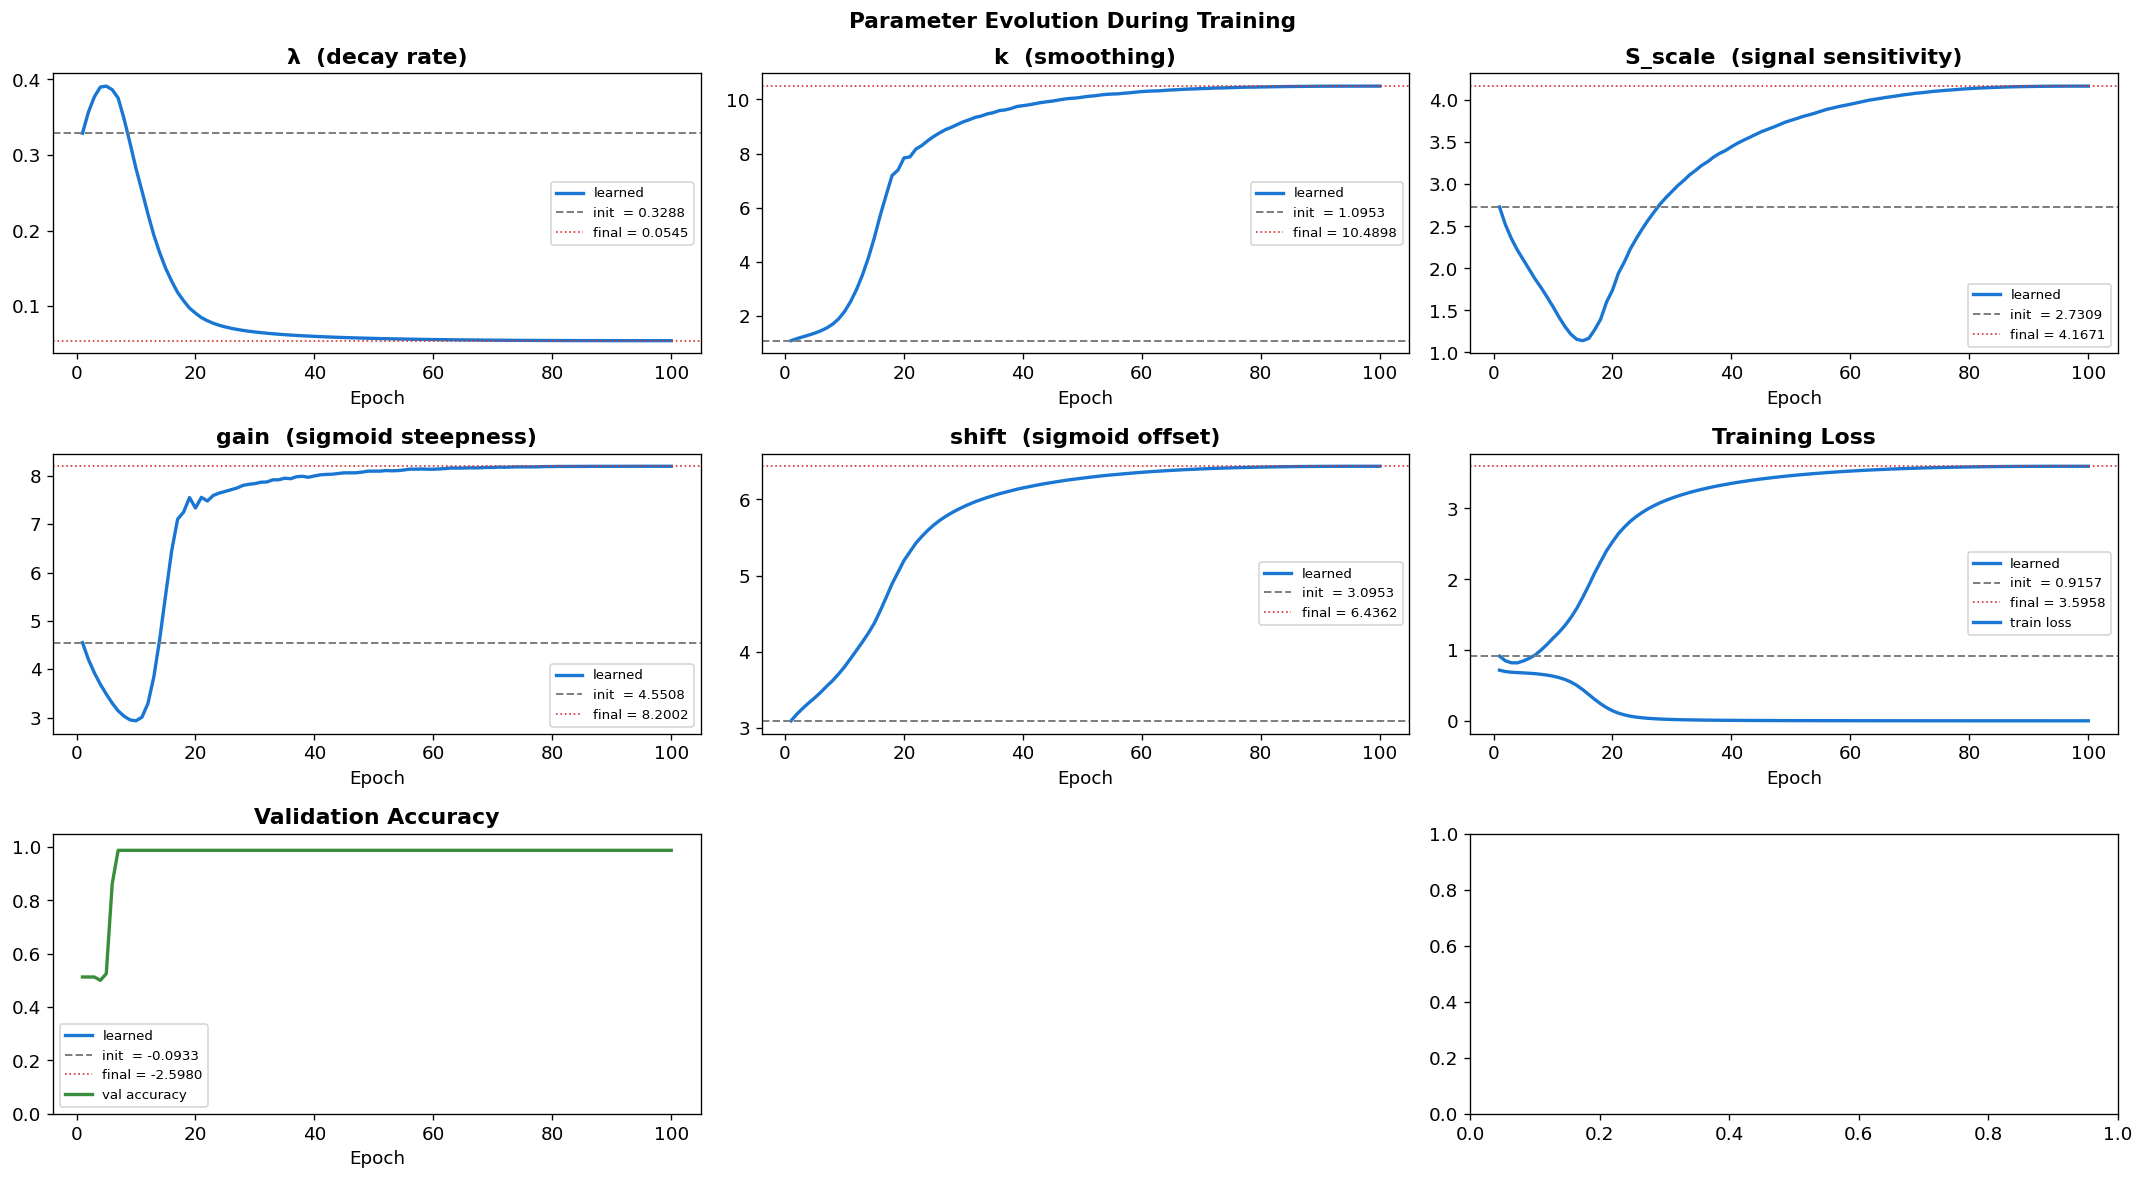

Saved: tau_learned_params.png


In [49]:
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
fig.suptitle('Parameter Evolution During Training', fontsize=13, fontweight='bold')

epochs_x = np.arange(1, EPOCHS + 1)

param_labels = {
    'lam':      'λ  (decay rate)',
    'k':        'k  (smoothing)',
    'S_scale':  'S_scale  (signal sensitivity)',
    'gain':     'gain  (sigmoid steepness)',
    'shift':    'shift  (sigmoid offset)',
    'v_target': 'v_target  (signal goal)',
    'v0':       'v0  (noise floor baseline)',
}

for ax, (pname, hist) in zip(axes.flat, param_history.items()):
    ax.plot(epochs_x, hist, lw=2, color='#1976D2', label='learned')
    ax.axhline(hist[0],  color='gray',    lw=1.2, ls='--', label=f'init  = {hist[0]:.4f}')
    ax.axhline(hist[-1], color='#D32F2F', lw=1.0, ls=':',  label=f'final = {hist[-1]:.4f}')
    ax.set_title(param_labels[pname], fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)

# Loss
ax = axes.flat[5]
ax.plot(epochs_x, train_losses, lw=2, color='#1976D2', label='train loss')
ax.set_title('Training Loss', fontweight='bold')
ax.set_xlabel('Epoch')
ax.legend(fontsize=8)

# Accuracy
ax = axes.flat[6]
ax.plot(epochs_x, val_accs, lw=2, color='#388E3C', label='val accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Validation Accuracy', fontweight='bold')
ax.set_xlabel('Epoch')
ax.legend(fontsize=8)

axes.flat[7].set_visible(False)

plt.tight_layout()
plt.savefig('tau_learned_params.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: tau_learned_params.png')

## 5 — τ Dynamics with Learned Parameters

Re-run the ODE simulation using the **learned** parameters to visualise τ(t) traces for LOS and NLOS captures.

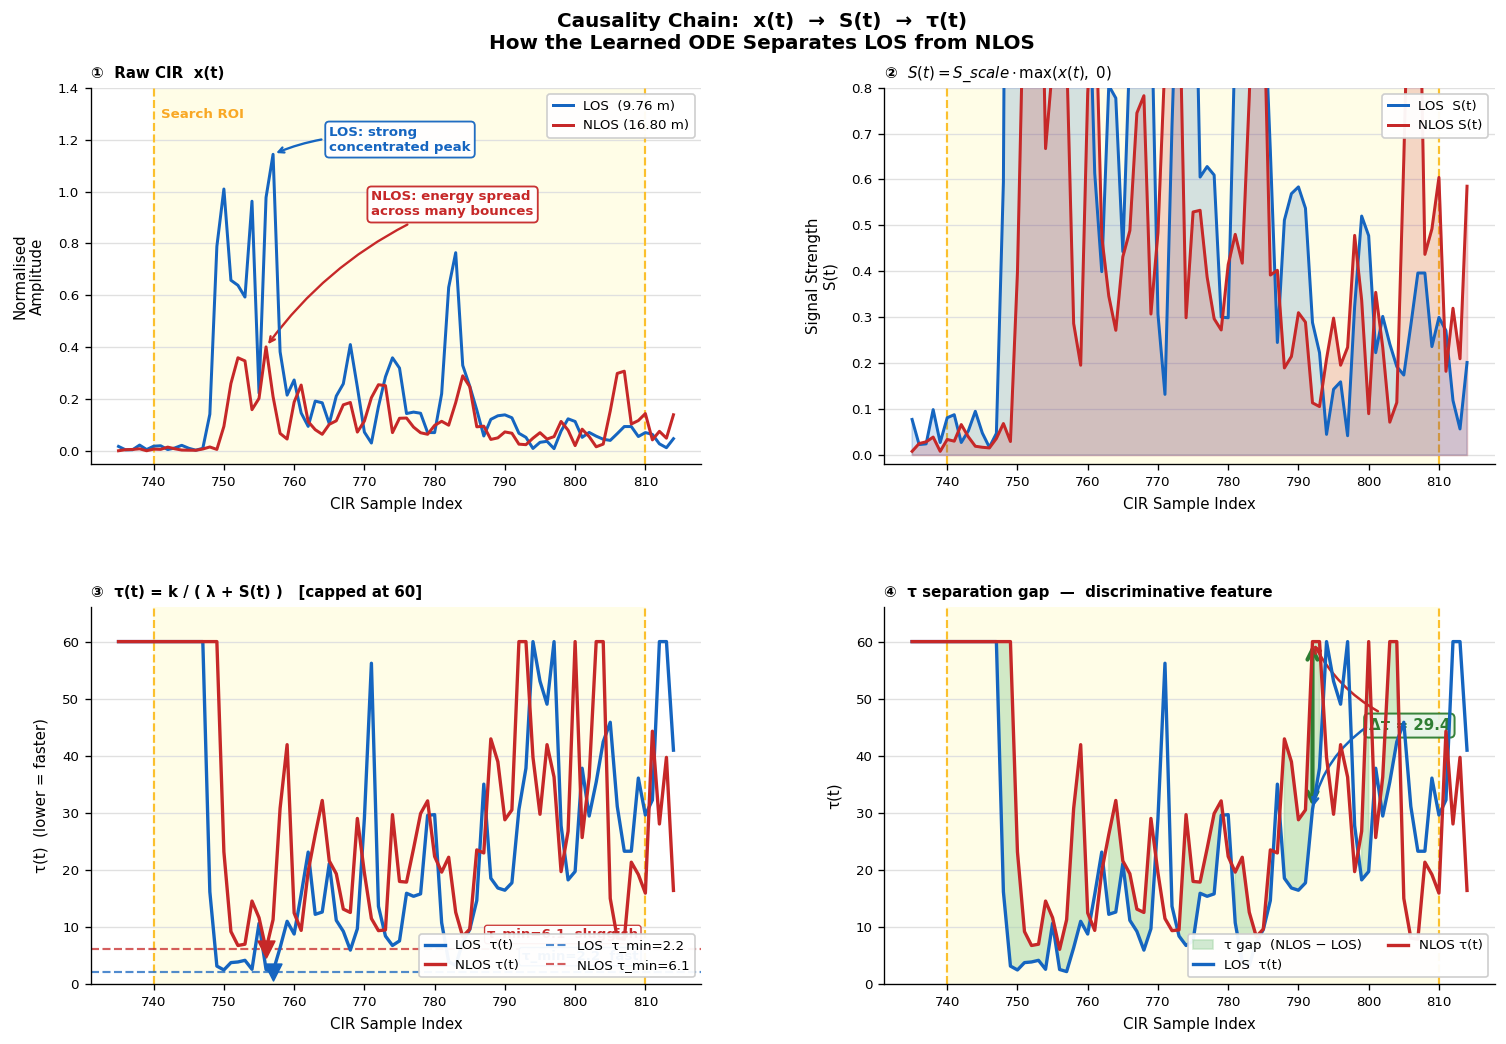

Saved: tau_learned_dynamics.png


In [50]:
def simulate_ode_np(cir_norm, lam, k, S_scale, v_target, v0=0.0, dt=1.0):
    """NumPy re-implementation of the learned ODE for visualisation.
    S(t) = S_scale · max(x(t), 0)
    """
    N = len(cir_norm)
    v_hist, S_hist, tau_hist = np.zeros(N), np.zeros(N), np.zeros(N)
    v = v0
    for i in range(N):
        x_t   = cir_norm[i]
        S_t   = S_scale * max(x_t, 0.0)
        tau_t = k / (lam + S_t + 1e-9)
        dv    = (dt / k) * (-lam * (v - v0) - S_t * (v - v_target) + x_t)
        v    += dv
        v_hist[i], S_hist[i], tau_hist[i] = v, S_t, tau_t
    return v_hist, S_hist, tau_hist

LRN = {k: v for k, v in model.get_params().items() if k in ('lam', 'k', 'S_scale', 'v_target', 'v0')}

def pick_median(cirs_norm):
    peaks = cirs_norm[:, SEARCH_START:SEARCH_END].max(axis=1)
    return cirs_norm[np.argsort(peaks)[len(peaks) // 2]]

cir_los_rep  = pick_median(los_norm)
cir_nlos_rep = pick_median(nlos_norm)
v_los,  S_los,  tau_los  = simulate_ode_np(cir_los_rep,  **LRN)
v_nlos, S_nlos, tau_nlos = simulate_ode_np(cir_nlos_rep, **LRN)

# ── Key indices ───────────────────────────────────────────────────────────────
ZOOM    = slice(735, 815)
t_zoom  = t_idx[ZOOM]
TAU_CAP = 60
C_LOS, C_NLOS = '#1565C0', '#C62828'

los_roi_tau  = tau_los [SEARCH_START:SEARCH_END]
nlos_roi_tau = tau_nlos[SEARCH_START:SEARCH_END]
los_tmin_idx  = SEARCH_START + int(np.argmin(los_roi_tau))
nlos_tmin_idx = SEARCH_START + int(np.argmin(nlos_roi_tau))
los_tmin_val  = tau_los [los_tmin_idx]
nlos_tmin_val = tau_nlos[nlos_tmin_idx]

los_pk_idx  = SEARCH_START + int(np.argmax(cir_los_rep [SEARCH_START:SEARCH_END]))
nlos_pk_idx = SEARCH_START + int(np.argmax(cir_nlos_rep[SEARCH_START:SEARCH_END]))

tau_los_cl  = np.clip(tau_los [ZOOM], 0, TAU_CAP)
tau_nlos_cl = np.clip(tau_nlos[ZOOM], 0, TAU_CAP)

# ── Shared style helpers ──────────────────────────────────────────────────────
def setup_panel(ax, ylabel, ylim=None):
    ax.axvspan(SEARCH_START, SEARCH_END, color='#FFFDE7', zorder=0)
    ax.axvline(SEARCH_START, color='#FBC02D', lw=1.3, ls='--', zorder=2)
    ax.axvline(SEARCH_END,   color='#FBC02D', lw=1.3, ls='--', zorder=2)
    ax.set_ylabel(ylabel, fontsize=9, labelpad=8)
    ax.tick_params(labelsize=8)
    ax.grid(axis='y', color='#e0e0e0', lw=0.8, zorder=1)
    ax.spines[['top','right']].set_visible(False)
    if ylim:
        ax.set_ylim(ylim)

def ann(ax, xy, xytext, text, color):
    ax.annotate(text, xy=xy, xytext=xytext,
                fontsize=8, color=color, fontweight='bold', va='center',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.4,
                                connectionstyle='arc3,rad=0.15'),
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          ec=color, lw=1.1, alpha=0.95))

# ── Figure — 2×2 layout ───────────────────────────────────────────────────────
plt.rcParams.update({'font.size': 9})
fig, axes = plt.subplots(2, 2, figsize=(13, 9),
                         gridspec_kw={'hspace': 0.38, 'wspace': 0.30,
                                      'top': 0.91, 'bottom': 0.08,
                                      'left': 0.07, 'right': 0.97})

fig.suptitle('Causality Chain:  x(t)  →  S(t)  →  τ(t)\n'
             'How the Learned ODE Separates LOS from NLOS',
             fontsize=12, fontweight='bold')

# ── Panel ① — Raw CIR  (top-left) ────────────────────────────────────────────
ax = axes[0, 0]
setup_panel(ax, ylabel='Normalised\nAmplitude', ylim=(-0.05, 1.40))
ax.set_title('①  Raw CIR  x(t)', fontsize=9, fontweight='bold', loc='left')
ax.plot(t_zoom, cir_los_rep[ZOOM],  color=C_LOS,  lw=1.8, label='LOS  (9.76 m)',  zorder=4)
ax.plot(t_zoom, cir_nlos_rep[ZOOM], color=C_NLOS, lw=1.8, label='NLOS (16.80 m)', zorder=4)
ax.text(SEARCH_START + 1, 1.32, 'Search ROI', fontsize=8,
        color='#F9A825', fontweight='bold', va='top')
ann(ax, xy=(los_pk_idx,  cir_los_rep[los_pk_idx]),
    xytext=(los_pk_idx + 8, 1.20),
    text='LOS: strong\nconcentrated peak', color=C_LOS)
ann(ax, xy=(nlos_pk_idx, cir_nlos_rep[nlos_pk_idx]),
    xytext=(nlos_pk_idx + 15, 0.95),
    text='NLOS: energy spread\nacross many bounces', color=C_NLOS)
ax.legend(fontsize=8, loc='upper right', framealpha=0.95,
          edgecolor='#ccc', handlelength=1.5)
ax.set_xlabel('CIR Sample Index', fontsize=9, labelpad=5)

# ── Panel ② — Signal Strength S(t)  (top-right) ──────────────────────────────
ax = axes[0, 1]
setup_panel(ax, ylabel='Signal Strength\nS(t)', ylim=(-0.02, 0.80))
ax.set_title(r'②  $S(t) = S\_scale \cdot \max(x(t),\; 0)$',
             fontsize=9, fontweight='bold', loc='left')
ax.fill_between(t_zoom, S_los[ZOOM],  alpha=0.18, color=C_LOS,  zorder=2)
ax.fill_between(t_zoom, S_nlos[ZOOM], alpha=0.18, color=C_NLOS, zorder=2)
ax.plot(t_zoom, S_los[ZOOM],  color=C_LOS,  lw=1.8, label='LOS  S(t)',  zorder=4)
ax.plot(t_zoom, S_nlos[ZOOM], color=C_NLOS, lw=1.8, label='NLOS S(t)', zorder=4)
s_los_max_idx  = SEARCH_START + int(np.argmax(S_los [SEARCH_START:SEARCH_END]))
s_nlos_max_idx = SEARCH_START + int(np.argmax(S_nlos[SEARCH_START:SEARCH_END]))
ann(ax, xy=(s_los_max_idx,  S_los[s_los_max_idx]),
    xytext=(s_los_max_idx + 12, 0.72),
    text='High S(t)  →  τ drops', color=C_LOS)
ann(ax, xy=(s_nlos_max_idx, S_nlos[s_nlos_max_idx]),
    xytext=(775, 0.50),
    text='Low S(t)  →  τ stays high', color=C_NLOS)
ax.legend(fontsize=8, loc='upper right', framealpha=0.95,
          edgecolor='#ccc', handlelength=1.5)
ax.set_xlabel('CIR Sample Index', fontsize=9, labelpad=5)

# ── Panel ③ — τ(t)  (bottom-left) ────────────────────────────────────────────
ax = axes[1, 0]
setup_panel(ax, ylabel='τ(t)  (lower = faster)', ylim=(0, TAU_CAP + 6))
ax.set_title(f'③  τ(t) = k / ( λ + S(t) )   [capped at {TAU_CAP}]',
             fontsize=9, fontweight='bold', loc='left')
ax.plot(t_zoom, tau_los_cl,  color=C_LOS,  lw=2.0, zorder=4, label='LOS  τ(t)')
ax.plot(t_zoom, tau_nlos_cl, color=C_NLOS, lw=2.0, zorder=4, label='NLOS τ(t)')
ax.axhline(min(los_tmin_val,  TAU_CAP), color=C_LOS,  lw=1.3, ls='--', alpha=0.75,
           label=f'LOS  τ_min={los_tmin_val:.1f}')
ax.axhline(min(nlos_tmin_val, TAU_CAP), color=C_NLOS, lw=1.3, ls='--', alpha=0.75,
           label=f'NLOS τ_min={nlos_tmin_val:.1f}')
ax.scatter(los_tmin_idx,  min(los_tmin_val,  TAU_CAP),
           color=C_LOS,  s=100, zorder=7, marker='v', clip_on=False)
ax.scatter(nlos_tmin_idx, min(nlos_tmin_val, TAU_CAP),
           color=C_NLOS, s=100, zorder=7, marker='v', clip_on=False)
ax.text(SEARCH_END - 1, min(los_tmin_val, TAU_CAP) + 2.0,
        f'τ_min={los_tmin_val:.1f}  fast', color=C_LOS,
        fontsize=8, ha='right', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=C_LOS, lw=0.8, alpha=0.9))
ax.text(SEARCH_END - 1, min(nlos_tmin_val, TAU_CAP) + 2.0,
        f'τ_min={nlos_tmin_val:.1f}  sluggish', color=C_NLOS,
        fontsize=8, ha='right', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=C_NLOS, lw=0.8, alpha=0.9))
ax.legend(fontsize=8, loc='lower right', framealpha=0.95,
          edgecolor='#ccc', handlelength=1.5, ncol=2)
ax.set_xlabel('CIR Sample Index', fontsize=9, labelpad=5)

# ── Panel ④ — Separation Gap  (bottom-right) ─────────────────────────────────
ax = axes[1, 1]
setup_panel(ax, ylabel='τ(t)', ylim=(0, TAU_CAP + 6))
ax.set_title('④  τ separation gap  —  discriminative feature',
             fontsize=9, fontweight='bold', loc='left')
ax.fill_between(t_zoom, tau_los_cl, tau_nlos_cl,
                where=(tau_nlos_cl >= tau_los_cl),
                color='#A5D6A7', alpha=0.50, zorder=2, label='τ gap  (NLOS − LOS)')
ax.plot(t_zoom, tau_los_cl,  color=C_LOS,  lw=2.0, zorder=4, label='LOS  τ(t)')
ax.plot(t_zoom, tau_nlos_cl, color=C_NLOS, lw=2.0, zorder=4, label='NLOS τ(t)')
right_half = slice(40, 65)
gap_arr    = tau_nlos_cl - tau_los_cl
right_gap  = gap_arr[right_half]
stable_idx = 40 + int(np.argmax(right_gap))
bx  = t_zoom[stable_idx]
y_lo = float(tau_los_cl [stable_idx])
y_hi = float(tau_nlos_cl[stable_idx])
# Thick vertical double-arrow showing the gap
ax.annotate('', xy=(bx, y_lo), xytext=(bx, y_hi),
            arrowprops=dict(arrowstyle='<->', color='#2E7D32', lw=2.5,
                            mutation_scale=15))
# Δτ label with arrows pointing to both LOS and NLOS lines
txt_x = bx + 8
txt_y = (y_lo + y_hi) / 2
ax.annotate(f'Δτ = {y_hi - y_lo:.1f}',
            xy=(bx, y_hi), xytext=(txt_x, txt_y),
            fontsize=9, color='#2E7D32', fontweight='bold', va='center', ha='left',
            arrowprops=dict(arrowstyle='->', color=C_NLOS, lw=1.5,
                            connectionstyle='arc3,rad=-0.2'),
            bbox=dict(boxstyle='round,pad=0.3', fc='#E8F5E9',
                      ec='#2E7D32', lw=1.2, alpha=0.95))
ax.annotate('',
            xy=(bx, y_lo), xytext=(txt_x, txt_y),
            arrowprops=dict(arrowstyle='->', color=C_LOS, lw=1.5,
                            connectionstyle='arc3,rad=0.2'))
ax.set_xlabel('CIR Sample Index', fontsize=9, labelpad=5)
ax.legend(fontsize=8, loc='lower right', framealpha=0.95,
          edgecolor='#ccc', handlelength=1.5, ncol=2)

plt.savefig('tau_learned_dynamics.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: tau_learned_dynamics.png')

## 6 — τ_min Separation across All Captures

Run the learned ODE over all captures and compare τ_min distributions between LOS and NLOS.

Computing τ_min for all captures...
Done.

Learned parameters:
  τ_min LOS  = 2.2147 ± 0.4721
  τ_min NLOS = 6.1408 ± 1.4204
  separation = 3.9261


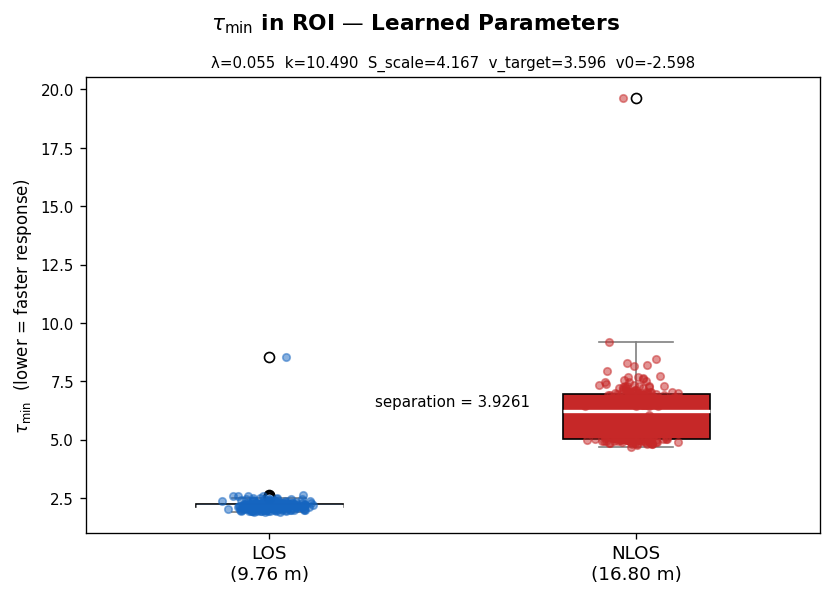

Saved: tau_learned_separation.png


In [51]:
def batch_tau_min(cirs_norm, params):
    """Compute τ_min in the ROI for every capture using given ODE params."""
    mins = []
    for cir in cirs_norm:
        _, _, tau = simulate_ode_np(cir, **params)
        mins.append(tau[SEARCH_START:SEARCH_END].min())
    return np.array(mins)

print('Computing τ_min for all captures...')
los_lrn  = batch_tau_min(los_norm,  LRN)
nlos_lrn = batch_tau_min(nlos_norm, LRN)
print('Done.')

print(f'\nLearned parameters:')
print(f'  τ_min LOS  = {los_lrn.mean():.4f} ± {los_lrn.std():.4f}')
print(f'  τ_min NLOS = {nlos_lrn.mean():.4f} ± {nlos_lrn.std():.4f}')
print(f'  separation = {nlos_lrn.mean() - los_lrn.mean():.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle(r'$\tau_{\min}$ in ROI — Learned Parameters', fontsize=13, fontweight='bold')

bp = ax.boxplot([los_lrn, nlos_lrn], patch_artist=True, widths=0.4,
                medianprops=dict(color='white', lw=2))
bp['boxes'][0].set_facecolor(C_LOS)
bp['boxes'][1].set_facecolor(C_NLOS)
for elem in ['whiskers', 'caps', 'fliers']:
    for patch in bp[elem]:
        patch.set_color('gray')

np.random.seed(0)
ax.scatter(np.random.normal(1, 0.05, len(los_lrn)),  los_lrn,
           color=C_LOS,  alpha=0.5, s=20, zorder=5)
ax.scatter(np.random.normal(2, 0.05, len(nlos_lrn)), nlos_lrn,
           color=C_NLOS, alpha=0.5, s=20, zorder=5)

ax.set_xticks([1, 2])
ax.set_xticklabels(['LOS\n(9.76 m)', 'NLOS\n(16.80 m)'], fontsize=11)
ax.set_ylabel(r'$\tau_{\min}$  (lower = faster response)', fontsize=10)
sep = nlos_lrn.mean() - los_lrn.mean()
ax.text(1.5, max(nlos_lrn.mean(), los_lrn.mean()) * 1.05,
        f'separation = {sep:.4f}', ha='center', fontsize=9)

ax.set_title(f'λ={LRN["lam"]:.3f}  k={LRN["k"]:.3f}  S_scale={LRN["S_scale"]:.3f}  '
             f'v_target={LRN["v_target"]:.3f}  v0={LRN["v0"]:.3f}',
             fontsize=9)

plt.tight_layout()
plt.savefig('tau_learned_separation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: tau_learned_separation.png')

## 7 — Summary

| Parameter | Role | Initial value | Learned value |
|-----------|------|---------------|---------------|
| λ (decay rate) | Signal decay rate | 0.3 | optimised from data |
| k (smoothing) | Smoothing factor | 1.0 | optimised from data |
| S_scale (signal sensitivity) | Scales positive CIR peaks into signal strength | 3.0 | optimised from data |
| v_target (signal goal) | Direction CIR feedback drives v(t) | 1.0 | optimised from data |
| v0 (noise floor) | Resting state when no signal | 0.0 | optimised from data |

**Key insight**: all ODE parameters are learned end-to-end via backpropagation through the unrolled ODE.
$S(t) = \text{S\_scale} \cdot \max(x(t), 0)$ — only positive CIR peaks drive the adaptive time constant.
The circuit discovers its own sensitivity, decay rate, and smoothing directly from the CIR data — no manual tuning required.